In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [2]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [3]:
%%capture
!pip install optuna torch plotly

In [4]:
# Import Packages
import os
import pandas as pd
import numpy as np
import datetime
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
import pickle as pkl
pd.set_option('display.max_columns', None)

In [5]:
from src.preprocessing.data_preparation import DataPreparation
from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.model.base_model.task_tcn import taskTCN
from src.utils.helper_functions import get_approach
from src.utils.evaluate import evaluate_model
from src.utils.train_task_tcn import train_task_tcn
from src.utils.test import quantile_test
from src.utils.postprocessing import process_quantile_data
from src.utils.metrics import quantile_performance_matrix

In [6]:
warnings.filterwarnings("ignore")
SEED = 1
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

best_val_loss = float('inf')

In [7]:
def one_hot_encode_column(dataframe, column_name):
    one_hot_encoded = pd.get_dummies(dataframe[column_name], prefix=column_name)
    dataframe = pd.concat([dataframe, one_hot_encoded], axis=1)
    dataframe = dataframe.drop(column_name, axis=1)

    return dataframe

In [8]:
def extract_trial_results(study):
    trials = study.trials
    results = []

    for trial in trials:
        hyperparameters = {
            "num_channels": trial.user_attrs.get("num_channels"),
            "kernel_size": trial.user_attrs.get("kernel_size"),
            "dropout": trial.user_attrs.get("dropout"),
            "learning_rate": trial.user_attrs.get("learning_rate"),
            "batch_size": trial.user_attrs.get("batch_size")
        }

        epoch_losses = []
        num_epochs = 0
        while True:
            epoch_train_loss = trial.user_attrs.get(f"train_loss_epoch_{num_epochs}", None)
            epoch_val_loss = trial.user_attrs.get(f"val_loss_epoch_{num_epochs}", None)

            if epoch_train_loss is not None and epoch_val_loss is not None:
                epoch_loss = {
                    "epoch": num_epochs,
                    "train_loss": epoch_train_loss,
                    "val_loss": epoch_val_loss
                }
                epoch_losses.append(epoch_loss)
                num_epochs += 1
            else:
                break

        result = {
            "trial_number": trial.number,
            "val_loss": trial.value,
            "hyperparameters": hyperparameters,
            "epoch_losses": epoch_losses
        }

        results.append(result)

    return results

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}\n")

Device: cuda



In [10]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):

    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=0)

In [11]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "MSE"
optimization_technique = "Optuna"

In [12]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
base_train_val_test_dir = train_val_test_dir + 'base_model'
result_dir = root_dir + 'result/'

# Base Directories
base_train_val_test_dir = train_val_test_dir + 'base_model/'
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'
base_loss_metrics_dir = base_result_dir + 'loss_metrics'
base_permormance_metrics_dir = base_result_dir + 'performance_metrics'
base_trial_metrics_dir = base_result_dir + 'trial_metrics'
base_test_result_dir = base_result_dir + 'test_result'

In [13]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 5
PATIENCE = 3

N_TRIALS = 5

In [14]:
study_name = f"Base Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

In [15]:
base_df = pd.read_csv(f'{preprocessed_dir}interVer_regular_caltech_acn_chargingSessions.csv')

In [16]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16550 entries, 0 to 16549
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   doneChargingTime            16550 non-null  object 
 1   clusterID                   16550 non-null  object 
 2   CA 91125                    16550 non-null  int64  
 3   CA 91106                    16550 non-null  int64  
 4   CA 91109                    16550 non-null  int64  
 5   CA 95136                    16550 non-null  int64  
 6   UniqueEVSEType              16550 non-null  object 
 7   EVSEcount                   16550 non-null  int64  
 8   EVSE_AV                     16550 non-null  int64  
 9   EVSE_CC32                   16550 non-null  int64  
 10  EVSE_CC64                   16550 non-null  int64  
 11  EVSE_DX                     16550 non-null  int64  
 12  EVSE_TWC                    16550 non-null  int64  
 13  UniquechargingReqType       165

In [17]:
base_df.head(5)

,doneChargingTime,clusterID,CA 91125,CA 91106,CA 91109,CA 95136,UniqueEVSEType,EVSEcount,EVSE_AV,EVSE_CC32,EVSE_CC64,EVSE_DX,EVSE_TWC,UniquechargingReqType,claimedCount,unclaimedCount,NotAvailable,UniqueFee,freeStationCount,paidStationCount,embedding_feature,Hour_of_Day,Day_Of_Week,Day_Of_year,Month_Of_Year,Time_of_day_0_4,Time_of_day_4_8,Time_of_day_8_12,Time_of_day_12_16,Time_of_day_16_20,Time_of_day_20_24,DayCategory,Season,daylightSaving,Smoothed_chargingTimeTotal,Smoothed_energyPriceTotal,lag_1,lag_2,Smoothed_kWhDeliveredTotal
0,2018-04-25 09:00:00,39,1,0,0,0,"AeroVironment, ClipperCreek32",26,21,5,0,0,0,Unclaimed,0,26,0,Free,26,0,0.492308,9,2,115,4,0,0,1,0,0,0,Weekday,2,1,1199.522443,0.0,29.270978,6.914062,53.214659
1,2018-04-25 10:00:00,39,1,0,0,0,"AeroVironment, ClipperCreek32",21,17,4,0,0,0,Unclaimed,0,21,0,Free,21,0,0.495238,10,2,115,4,0,0,1,0,0,0,Weekday,2,1,1228.985719,0.0,53.214659,29.270978,51.821083
2,2018-04-25 11:00:00,39,1,0,0,0,"AeroVironment, ClipperCreek32",16,12,4,0,0,0,Unclaimed,0,16,0,Free,16,0,0.493750,11,2,115,4,0,0,1,0,0,0,Weekday,2,1,833.032859,0.0,51.821083,53.214659,35.835184
3,2018-04-25 12:00:00,39,1,0,0,0,"AeroVironment, ClipperCreek32",8,6,2,0,0,0,Unclaimed,0,8,0,Free,8,0,0.500000,12,2,115,4,0,0,0,1,0,0,Weekday,2,1,455.826829,0.0,35.835184,51.821083,20.583413
4,2018-04-25 13:00:00,39,1,0,0,0,"AeroVironment, ClipperCreek32",9,7,2,0,0,0,Unclaimed,0,9,0,Free,9,0,0.494444,13,2,115,4,0,0,0,1,0,0,Weekday,2,1,502.478768,0.0,20.583413,35.835184,24.614717


In [18]:
object_columns = base_df.select_dtypes(include=['object'])
for column in object_columns.columns:
    print(f"Column '{column}' has {object_columns[column].nunique()} unique values.")

Column 'doneChargingTime' has 16550 unique values.
Column 'clusterID' has 22 unique values.
Column 'UniqueEVSEType' has 30 unique values.
Column 'UniquechargingReqType' has 8 unique values.
Column 'UniqueFee' has 3 unique values.
Column 'DayCategory' has 15 unique values.


In [19]:
base_df = one_hot_encode_column(base_df, 'UniqueFee')

In [20]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16550 entries, 0 to 16549
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   doneChargingTime            16550 non-null  object 
 1   clusterID                   16550 non-null  object 
 2   CA 91125                    16550 non-null  int64  
 3   CA 91106                    16550 non-null  int64  
 4   CA 91109                    16550 non-null  int64  
 5   CA 95136                    16550 non-null  int64  
 6   UniqueEVSEType              16550 non-null  object 
 7   EVSEcount                   16550 non-null  int64  
 8   EVSE_AV                     16550 non-null  int64  
 9   EVSE_CC32                   16550 non-null  int64  
 10  EVSE_CC64                   16550 non-null  int64  
 11  EVSE_DX                     16550 non-null  int64  
 12  EVSE_TWC                    16550 non-null  int64  
 13  UniquechargingReqType       165

In [21]:
datetime_column = ['doneChargingTime']
categorical_features = ['clusterID', 'UniqueEVSEType', 'UniquechargingReqType', 'DayCategory']

continuous_features = ['EVSEcount', 'EVSE_AV', 'EVSE_CC32', 'EVSE_CC64', 'EVSE_DX', 'EVSE_TWC', 'claimedCount', 'unclaimedCount', 'NotAvailable', 'freeStationCount',
                     'paidStationCount', 'embedding_feature', 'Smoothed_chargingTimeTotal', 'Smoothed_energyPriceTotal', 'lag_1', 'lag_2', 'Smoothed_kWhDeliveredTotal']

one_hot_features = ['CA 91125', 'CA 91106', 'CA 91109', 'CA 95136', 'Time_of_day_0_4', 'Time_of_day_4_8','Time_of_day_8_12', 'Time_of_day_12_16', 'Time_of_day_16_20',
                  'Time_of_day_20_24', 'daylightSaving', 'UniqueFee_Free', 'UniqueFee_NoFeeApplicable', 'UniqueFee_Paid']

temporal_features = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year', 'Season']

In [22]:
base_df_scaled, base_df_scaling_params = min_max_scaling(df = base_df, minmax_cols=continuous_features, sin_cos_cols=temporal_features, column_name='Smoothed_kWhDeliveredTotal')

In [23]:
base_timestamp_list = base_df_scaled["doneChargingTime"].tolist()

In [24]:
base_df_scaled.sample(2)

,doneChargingTime,clusterID,CA 91125,CA 91106,CA 91109,CA 95136,UniqueEVSEType,EVSEcount,EVSE_AV,EVSE_CC32,EVSE_CC64,EVSE_DX,EVSE_TWC,UniquechargingReqType,claimedCount,unclaimedCount,NotAvailable,freeStationCount,paidStationCount,embedding_feature,Time_of_day_0_4,Time_of_day_4_8,Time_of_day_8_12,Time_of_day_12_16,Time_of_day_16_20,Time_of_day_20_24,DayCategory,daylightSaving,Smoothed_chargingTimeTotal,Smoothed_energyPriceTotal,lag_1,lag_2,Smoothed_kWhDeliveredTotal,UniqueFee_Free,UniqueFee_NoFeeApplicable,UniqueFee_Paid,Hour_of_Day_sin,Hour_of_Day_cos,Day_Of_Week_sin,Day_Of_Week_cos,Day_Of_year_sin,Day_Of_year_cos,Month_Of_Year_sin,Month_Of_Year_cos,Season_sin,Season_cos
9174,2019-05-12 15:00:00,"39, 105, 6",1,1,0,0,"AeroVironment, TeslaWallConnect",0.166667,0.114286,0.0,0.0,0.0,0.333333,"Claimed, NotAvailable",0.111111,0.0,0.222222,0.0,0.166667,0.769231,0,0,0,1,0,0,WeeekendSunday,1,0.131794,0.209190,0.260771,1.376725e-01,0.208084,0,0,1,-0.81697,-0.57668,-2.449294e-16,1.0,0.763889,-0.645348,0.5,-0.866025,1.224647e-16,-1.0
9479,2019-05-25 08:00:00,6,1,0,0,0,TeslaWallConnect,0.023810,0.000000,0.0,0.0,0.0,0.111111,NotAvailable,0.000000,0.0,0.055556,0.0,0.023810,0.692308,0,0,1,0,0,0,WeekendSaturday,1,0.026595,0.073835,0.036415,2.414821e-10,0.073444,0,0,1,0.81697,-0.57668,-8.660254e-01,0.5,0.601624,-0.798779,0.5,-0.866025,1.224647e-16,-1.0


In [25]:
temporal_encoding = ['Hour_of_Day_sin',	'Hour_of_Day_cos',	'Day_Of_Week_sin',	'Day_Of_Week_cos',	'Day_Of_year_sin',	'Day_Of_year_cos',	'Month_Of_Year_sin',
                     'Month_Of_Year_cos',	'Season_sin',	'Season_cos']
numerical_data = continuous_features + one_hot_features + temporal_encoding

In [26]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    base_df_scaled[feature] = le.fit_transform(base_df_scaled[feature])
    label_encoders[feature] = le

In [27]:
base_df_scaled = base_df_scaled[datetime_column + numerical_data + categorical_features]

In [28]:
base_df_scaled.sample(2)

,doneChargingTime,EVSEcount,EVSE_AV,EVSE_CC32,EVSE_CC64,EVSE_DX,EVSE_TWC,claimedCount,unclaimedCount,NotAvailable,freeStationCount,paidStationCount,embedding_feature,Smoothed_chargingTimeTotal,Smoothed_energyPriceTotal,lag_1,lag_2,Smoothed_kWhDeliveredTotal,CA 91125,CA 91106,CA 91109,CA 95136,Time_of_day_0_4,Time_of_day_4_8,Time_of_day_8_12,Time_of_day_12_16,Time_of_day_16_20,Time_of_day_20_24,daylightSaving,UniqueFee_Free,UniqueFee_NoFeeApplicable,UniqueFee_Paid,Hour_of_Day_sin,Hour_of_Day_cos,Day_Of_Week_sin,Day_Of_Week_cos,Day_Of_year_sin,Day_Of_year_cos,Month_Of_Year_sin,Month_Of_Year_cos,Season_sin,Season_cos,clusterID,UniqueEVSEType,UniquechargingReqType,DayCategory
11537,2019-08-19 02:00:00,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000004,0.000008,0.000820,0.082001,0.000008,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0.519584,0.854419,0.000000e+00,1.0,-0.741222,-0.67126,-0.866025,-5.000000e-01,-1.000000e+00,-1.836970e-16,21,26,6,13
7995,2019-03-24 12:00:00,0.095238,0.085714,0.0,0.090909,0.0,0.0,0.074074,0.026316,0.055556,0.0,0.095238,0.75,0.079994,0.064443,0.030338,0.077484,0.064191,1,0,0,0,0,0,0,1,0,0,1,0,0,1,-0.136167,-0.990686,-2.449294e-16,1.0,0.989932,0.14154,1.000000,6.123234e-17,1.224647e-16,-1.000000e+00,14,9,2,12


In [29]:
total_data_points = len(base_df_scaled)

train_size = int(0.7 * total_data_points)
val_size = int(0.2 * total_data_points)
test_size = total_data_points - train_size - val_size

base_train_df = base_df_scaled.iloc[:train_size]
base_val_df = base_df_scaled.iloc[train_size:train_size + val_size]
base_test_df = base_df_scaled.iloc[train_size + val_size:]

In [30]:
base_train_df.shape, base_val_df.shape, base_test_df.shape

((11585, 46), (3310, 46), (1655, 46))

In [31]:
# base_train_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv',
#     index=False)
# base_val_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv',
#     index=False)
# base_test_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv',
#     index=False)

# BASE_TRAIN_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv'
# BASE_VAL_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv'
# BASETEST_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv'

In [32]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST, n_categorical_features = len(categorical_features))

In [33]:
_ , base_x_con_train, base_x_cat_train, base_y_train = dp.prepare_data(dataframe = base_train_df)
_ , base_x_con_val, base_x_cat_val, base_y_val = dp.prepare_data(dataframe = base_val_df)
_ , base_x_con_test, base_x_cat_test, base_y_test = dp.prepare_data(dataframe = base_test_df)

In [34]:
base_x_con_train.shape, base_x_cat_train.shape, base_y_train.shape, base_x_con_val.shape, base_x_cat_val.shape, base_y_val.shape, base_x_con_test.shape, base_x_cat_test.shape, base_y_test.shape

((11394, 168, 41),
 (11394, 168, 4),
 (11394, 24),
 (3119, 168, 41),
 (3119, 168, 4),
 (3119, 24),
 (1464, 168, 41),
 (1464, 168, 4),
 (1464, 24))

In [35]:
# base_x_con_train = base_x_con_train[:128]
# base_x_cat_train = base_x_cat_train[:128]
# base_y_train = base_y_train[:128]
# base_x_con_val = base_x_con_val[:128]
# base_x_cat_val = base_x_cat_val[:128]
# base_y_val = base_y_val[:128]
# base_x_con_test = base_x_con_test[:128]
# base_x_cat_test = base_x_cat_test[:128]
# base_y_test = base_y_test[:128]

In [36]:
base_train_data = TensorDataset(torch.from_numpy(base_x_con_train).float(), torch.from_numpy(base_x_cat_train).long(), torch.from_numpy(base_y_train).float())
base_val_data = TensorDataset(torch.from_numpy(base_x_con_val).float(), torch.from_numpy(base_x_cat_val).long(), torch.from_numpy(base_y_val).float())
base_test_data = TensorDataset(torch.from_numpy(base_x_con_test).float(), torch.from_numpy(base_x_cat_test).long(), torch.from_numpy(base_y_test).float())

In [37]:
N_TRIALS = 5
EPOCHS = 2

In [38]:
unique_values = [base_df_scaled[column].nunique() for column in categorical_features]
unique_values

[22, 30, 8, 15]

In [39]:
from fastai.tabular.model import emb_sz_rule

def get_emb_sz_list(dims: list):
    """
    For all elements in the given list, find a size for the respective embedding through trial and error
    Each element denotes the amount of unique values for one categorical feature
    Parameters
    ----------
    dims : list
        a list containing a number of integers.
    Returns
    -------
    list of tupels
        a list containing an the amount of unique values and respective embedding size for all elements.
    """
    return [(d, emb_sz_rule(d)) for d in dims]

In [40]:
a = get_emb_sz_list(unique_values)
a

[(22, 9), (30, 11), (8, 5), (15, 7)]

In [41]:
base_train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=64, shuffle=False)
base_val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=64, shuffle=False)

In [42]:
base_model = taskTCN(input_size=base_x_con_train.shape[2], embedding_dims=a, num_channels=[128]*5,
                    kernel_size=3, dropout=0.02, output_size=base_y_train.shape[1]).to(DEVICE)

In [43]:
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=0.0001, weight_decay=1e-4)
base_loss_fn = nn.MSELoss()

In [44]:
base_model_name = f'{common_file_name}.pt'
base_model_path = os.path.join(base_model_dir, base_model_name)

In [45]:
base_train_loss, base_val_loss = train_task_tcn(device = DEVICE, model = base_model, optimizer = base_optimizer, loss_fn = base_loss_fn, train_loader = base_train_loader,
                                                val_loader = base_val_loader, epochs = 20, patience = 2, filename=base_model_path)
print(f'\nThe base trained model: {base_model_name} has been successfully saved: "{base_model_path}".\n')

Training:   5%|▌         | 1/20 [05:09<1:37:51, 309.04s/it]

Epoch 1/20: Train Loss = 0.0156, Validation Loss = 0.0140


Training:  10%|█         | 2/20 [10:05<1:30:27, 301.55s/it]

Epoch 2/20: Train Loss = 0.0087, Validation Loss = 0.0116


Training:  15%|█▌        | 3/20 [15:01<1:24:45, 299.16s/it]

...

Training:  35%|███▌      | 7/20 [34:49<1:04:22, 297.10s/it]

Epoch 7/20: Train Loss = 0.0055, Validation Loss = 0.0097


Training:  40%|████      | 8/20 [39:41<59:06, 295.56s/it]  

Epoch 8/20: Train Loss = 0.0054, Validation Loss = 0.0098


Epoch 9/20: Train Loss = 0.0053, Validation Loss = 0.0098
Early stopping after 2 epochs of no improvement in validation loss.

The base trained model: TL_BM_TCN_1.0_MSE_Optuna_7.0_1.0_04112023.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/model/TL_BM_TCN_1.0_MSE_Optuna_7.0_1.0_04112023.pt".



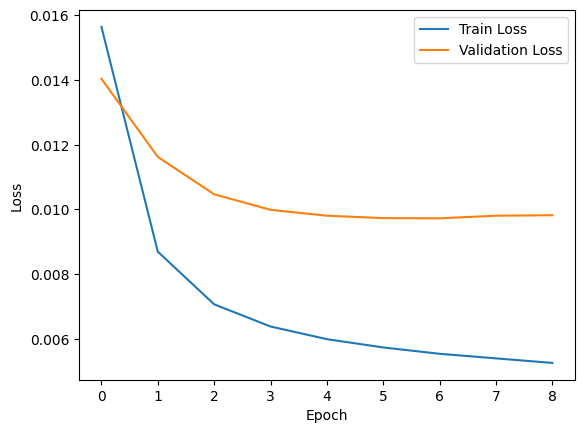

In [46]:
plt.plot(base_train_loss, label='Train Loss')
plt.plot(base_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [47]:
base_test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=64, shuffle=False)

In [48]:
def test(device, model, test_loader, loss_fn):
    test_loss = 0.0
    preds = []
    model.to(device)
    model.eval()
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.permute(0, 2, 1))
            loss = loss_fn(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
            preds.append(outputs.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    test_loss /= len(test_loader.dataset)
    print(f'Test Loss: {test_loss:.4f}\n')
    return test_loss, preds

In [49]:
import torch
import numpy as np

def test(device, model, test_loader, loss_fn):
    test_loss = 0.0
    preds = []
    model.to(device)
    model.eval()
    with torch.no_grad():
        for x_con_batch, x_cat_batch, y_batch in test_loader:
            x_con_batch, x_cat_batch, y_batch = x_con_batch.to(device), x_cat_batch.to(device), y_batch.to(device)
            outputs = model(x_con_batch, x_cat_batch)
            loss = loss_fn(outputs, y_batch)
            test_loss += loss.item() * x_con_batch.size(0)
            preds.append(outputs.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    test_loss /= len(test_loader.dataset)
    print(f'Test Loss: {test_loss:.4f}\n')
    return test_loss, preds

In [50]:
if os.path.exists(base_model_path):
    base_model = taskTCN(input_size=base_x_con_train.shape[2], embedding_dims=a, num_channels=[128]*5,
                    kernel_size=3, dropout=0.02, output_size=base_y_train.shape[1]).to(DEVICE)
    base_model.load_state_dict(torch.load(base_model_path))
    base_model.eval()
    base_test_loss, base_y_pred = test(device=DEVICE, model=base_model, test_loader = base_test_loader, loss_fn = base_loss_fn)
else:
    print(f"File not found at path: {base_model_path}\n")

Test Loss: 0.0100



In [51]:
base_y_pred.shape

(1464, 24)

In [52]:
from src.utils.postprocessing import process_data

In [53]:
def process_data(y_test, y_pred, scaling_type, scaling_params, timestamp_list, train_df, val_df, scaled_df, n_past, n_future):
    columns = ['t+' + str(i) for i in range(1, y_test.shape[1] + 1)]
    y_test_df = pd.DataFrame(y_test.reshape(y_test.shape[0], -1), columns=columns)
    y_pred_df = pd.DataFrame(y_pred.reshape(y_pred.shape[0], -1), columns=columns)
    col_index = y_test_df.columns.get_loc('t+1')

    if scaling_type == 'robust':
        scaling_param = scaling_params['Smoothed_kWhDeliveredTotal']
        robust_center, robust_scale = np.array(scaling_param)
        y_test_df.iloc[:, col_index] = y_test_df.iloc[:, col_index] * robust_scale + robust_center
        y_pred_df.iloc[:, col_index] = y_pred_df.iloc[:, col_index] * robust_scale + robust_center
    elif scaling_type == 'min_max':
        scaling_param = scaling_params['Smoothed_kWhDeliveredTotal']
        min_value, max_value = np.array(scaling_param)
        y_test_df.iloc[:, col_index] = y_test_df.iloc[:, col_index] * (max_value - min_value) + min_value
        y_pred_df.iloc[:, col_index] = y_pred_df.iloc[:, col_index] * (max_value - min_value) + min_value

    y_test_df = y_test_df.iloc[:, 0]
    y_pred_df = y_pred_df.iloc[:, 0]
    y_test_org = y_test_df.copy()
    y_test_pred = y_pred_df.copy()

    if y_test.shape[0] == 128:
        doneChargingTime_subset = timestamp_list[len(train_df)+len(val_df)+n_past:len(scaled_df)-(n_future)+1]
        doneChargingTime_subset = doneChargingTime_subset[:128]
    else:
        doneChargingTime_subset = timestamp_list[len(train_df)+len(val_df)+n_past:len(scaled_df)-(n_future)+1]
    result_df = pd.DataFrame({'y_test_org': y_test_org, 'y_test_pred': y_test_pred})
    result_df.insert(0, 'doneChargingTime', doneChargingTime_subset)
    result_df['doneChargingTime'] = pd.to_datetime(result_df['doneChargingTime'])
    result_df_daily_mean = result_df.copy()
    result_df_daily_mean = result_df_daily_mean.set_index('doneChargingTime')
    result_df_daily_mean = result_df_daily_mean.resample('D').mean()
    result_df_daily_mean = result_df_daily_mean.reset_index()

    result_df_daily_total = result_df.copy()
    result_df_daily_total = result_df_daily_total.set_index('doneChargingTime')
    result_df_daily_total = result_df_daily_total.resample('D').sum()
    result_df_daily_total = result_df_daily_total.reset_index()

    return result_df, result_df_daily_total, result_df_daily_mean

In [54]:
base_result_df, base_result_df_daily_total, base_result_df_daily_mean = process_data(
    y_test=base_y_test,
    y_pred=base_y_pred,
    scaling_type = 'min_max',
    scaling_params=base_df_scaling_params,
    timestamp_list=base_timestamp_list,
    train_df=base_train_df,
    val_df=base_val_df,
    scaled_df=base_df_scaled,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [60]:
base_result_df.describe()

,y_test_org,y_test_pred
count,1.464000e+03,1464.000000
mean,1.918710e+01,15.405274
std,2.371758e+01,16.701477
min,7.076793e-26,-6.312254
25%,7.848168e-02,2.100355
50%,1.026386e+01,12.166063
75%,2.901359e+01,21.836738
max,1.463353e+02,77.214134


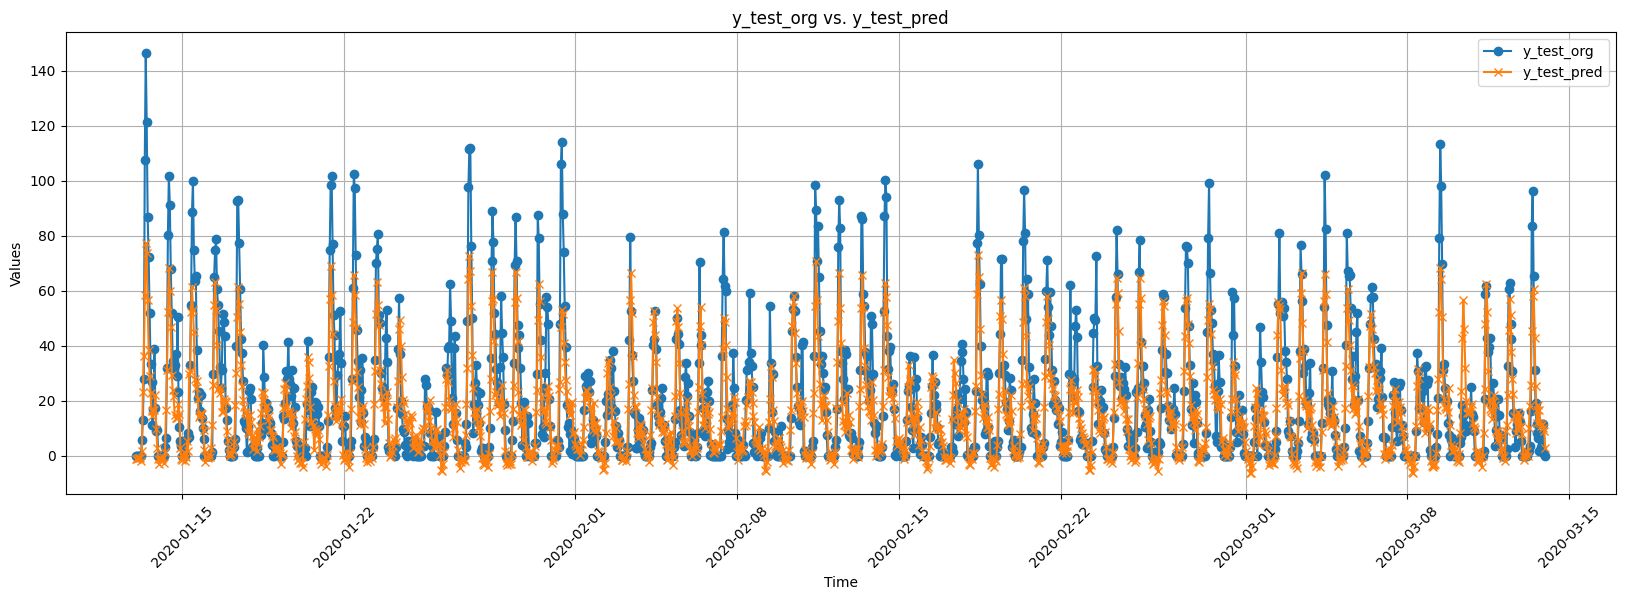

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
base_result_df['doneChargingTime'] = pd.to_datetime(base_result_df['doneChargingTime'])

base_result_df = base_result_df.sort_values(by='doneChargingTime')

plt.figure(figsize=(20, 6))
plt.plot(base_result_df['doneChargingTime'], base_result_df['y_test_org'], label='y_test_org', marker='o')
plt.plot(base_result_df['doneChargingTime'], base_result_df['y_test_pred'], label='y_test_pred', marker='x')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('y_test_org vs. y_test_pred')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

In [59]:
import plotly.express as px
import pandas as pd

base_result_df['doneChargingTime'] = pd.to_datetime(base_result_df['doneChargingTime'])
base_result_df = base_result_df.sort_values(by='doneChargingTime')
fig = px.line(base_result_df, x='doneChargingTime', y=['y_test_org', 'y_test_pred'],
              labels={'doneChargingTime': 'Time', 'value': 'Values'}, markers=True)

fig.update_layout(
    title='y_test_org vs. y_test_pred',
    xaxis=dict(tickangle=-45),
    showlegend=True,
    legend=dict(title=None)
)

fig.show()

In [57]:
-----

SyntaxError: ignored

In [ ]:
from tqdm import tqdm

def objective(trial, epochs):
    global best_val_loss

    num_channels = trial.suggest_categorical('num_channels',
                                             [[2 ** i] * (j + 1) for i in range(4, 7) for j in range(0, 2)])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = epochs

    train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = taskTCN(input_size=base_x_con_train.shape[2], embedding_dims=a, num_channels=num_channels,
                    kernel_size=kernel_size, dropout=dropout, output_size=base_y_train.shape[1]).to(DEVICE)

    print(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    results = []
    train_loss = []
    val_loss = []

    for epoch in tqdm(range(epochs), desc="Training", dynamic_ncols=True, leave=False):
        model.train()
        epoch_train_loss = []
        for x_con_batch, x_cat_batch, y_batch in train_loader:
            x_con_batch, x_cat_batch, y_batch = x_con_batch.to(DEVICE), x_cat_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(x_con_batch, x_cat_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        model.eval()
        epoch_val_loss = []
        with torch.no_grad():
            for x_con_batch, x_cat_batch, y_batch in val_loader:
                x_con_batch, x_cat_batch, y_batch = x_con_batch.to(DEVICE), x_cat_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(x_con_batch, x_cat_batch)
                loss = loss_fn(outputs, y_batch)
                epoch_val_loss.append(loss.item())
        avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
        val_loss.append(avg_val_loss)

        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        trial.set_user_attr("num_channels", num_channels)
        trial.set_user_attr("kernel_size", kernel_size)
        trial.set_user_attr("dropout", dropout)
        trial.set_user_attr("learning_rate", learning_rate)
        trial.set_user_attr("batch_size", batch_size)
        trial.set_user_attr(f"train_loss_epoch_{epoch}", avg_train_loss)
        trial.set_user_attr(f"val_loss_epoch_{epoch}", avg_val_loss)

        if avg_val_loss < best_val_loss:
            # Save the best model
            best_val_loss = avg_val_loss
            if not os.path.exists(os.path.dirname(base_model_path)):
                os.makedirs(os.path.dirname(base_model_path))
            torch.save(model.state_dict(), base_model_path)

    return avg_val_loss


In [ ]:
base_model_name = f'{common_file_name}.pt'
base_model_path = os.path.join(base_model_dir, base_model_name)
print("Hyperparameter Searching started..................\n")
study = optuna.create_study(study_name=study_name, direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lambda trial: objective(trial, epochs=EPOCHS), n_trials=N_TRIALS)
print(f'\nThe base trained model: {base_model_name} has been successfully saved: "{base_model_path}".\n')

In [ ]:
--

In [ ]:
study_results = extract_trial_results(study)

In [ ]:
trial_result_file = f"{common_file_name}_trial_loss_metrics.pkl"
trial_result_path = os.path.join(base_trial_metrics_dir, trial_result_file)

with open(trial_result_path, "wb") as f:
    pkl.dump(study_results, f)

print(f"Base Trial results: '{trial_result_file}' have been successfully saved: {trial_result_path}.\n")

In [ ]:
print(f'  Best trial: {study.best_trial.number}')
print(f'  num_channels: {study.best_trial.params["num_channels"]}')
print(f'  kernel_size: {study.best_trial.params["kernel_size"]}')
print(f'  dropout: {study.best_trial.params["dropout"]}')
print(f'  learning_rate: {study.best_trial.params["learning_rate"]}')
print(f'  batch_size: {study.best_trial.params["batch_size"]}\n')

In [ ]:
best_num_channels = study.best_trial.params["num_channels"]
best_kernel_size = study.best_trial.params["kernel_size"]
best_dropout = study.best_trial.params["dropout"]
best_learning_rate = study.best_trial.params["learning_rate"]
best_batch_size = study.best_trial.params["batch_size"]

In [ ]:
base_test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=best_batch_size, shuffle=False)

In [ ]:
if os.path.exists(base_model_path):
    base_model = QuantileTCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=best_num_channels,
                kernel_size=best_kernel_size, dropout=best_dropout, quantiles=QUANTILES)
    base_model.load_state_dict(torch.load(base_model_path))
    base_model.eval()
    base_test_loss, base_test_list, base_y_pred = quantile_test(device=DEVICE, model=base_model, test_loader = base_test_loader, quantiles=QUANTILES)
else:
    print(f"File not found at path: {base_model_path}\n")

In [ ]:
print(base_y_test.shape, base_y_pred.shape)

In [ ]:
base_result_df_hourly, base_result_df_daily_mean,  base_result_df_daily_total= process_quantile_data(
    y_test=base_y_test,
    y_pred=base_y_pred,
    quantiles = QUANTILES,
    scaling_type = 'min_max',
    scaling_params= base_df_scaling_params,
    timestamp_list=base_timestamp_list,
    train_df=base_train_df,
    val_df=base_val_df,
    scaled_df=base_df_scaled,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [ ]:
base_result_df_file_name = f'{common_file_name}_base_result_df_hourly.pkl'
base_result_df_file_path = os.path.join(base_test_result_dir, base_result_df_file_name)
base_result_df_hourly.to_pickle(base_result_df_file_path)
print(f"Base result DataFrame {base_result_df_file_name} has been successfully saved: {base_result_df_file_path}.\n")

base_result_df_daily_file_name = f'{common_file_name}_base_result_df_daily_total.pkl'
base_result_df_daily_file_path = os.path.join(base_test_result_dir, base_result_df_daily_file_name)
base_result_df_daily_total.to_pickle(base_result_df_daily_file_path)
print(f"Base result daily DataFrame {base_result_df_daily_file_name} has been successfully saved: {base_result_df_daily_file_path}.\n")

base_result_df_daily_file_name = f'{common_file_name}_base_result_df_daily.pkl'
base_result_df_daily_file_path = os.path.join(base_test_result_dir, base_result_df_daily_file_name)
base_result_df_daily_mean.to_pickle(base_result_df_daily_file_path)
print(f"Base result daily DataFrame {base_result_df_daily_file_name} has been successfully saved: {base_result_df_daily_file_path}.\n")

ref: https://gist.github.com/bshishov/5dc237f59f019b26145648e2124ca1c9
ref: https://www.geeksforgeeks.org/how-to-calculate-smape-in-python/

In [ ]:
error_matrix_hourly = quantile_performance_matrix(base_result_df_hourly['y_test_org'], base_result_df_hourly['y_test_pred_q2'], base_result_df_hourly['y_test_pred_q3'])
error_matrix_daily_avg = quantile_performance_matrix(base_result_df_daily_total['y_test_org'], base_result_df_daily_total['y_test_pred_q2'], base_result_df_daily_total['y_test_pred_q3'])
error_matrix_daily_total = quantile_performance_matrix(base_result_df_daily_mean['y_test_org'], base_result_df_daily_mean['y_test_pred_q2'], base_result_df_daily_mean['y_test_pred_q3'])

In [ ]:
error_matrix_hourly
error_matrix_hourly['test_loss'] = base_test_loss
error_matrix_hourly['test_loss_list'] = [str(base_test_list)]

In [ ]:
error_matrix_hourly_name = f'{common_file_name}_error_matrix_df_hourly.pkl'
error_martix_path = os.path.join(base_permormance_metrics_dir, error_matrix_hourly_name)
error_matrix_hourly.to_pickle(error_martix_path)
print(f"Performance Matrix DataFrame {error_matrix_hourly_name} has been successfully saved: {error_martix_path}.\n")

error_matrix_daily_total_name = f'{common_file_name}_error_matrix_df_daily_total.pkl'
error_martix_path = os.path.join(base_permormance_metrics_dir, error_matrix_daily_total_name)
error_matrix_daily_total.to_pickle(error_martix_path)
print(f"Performance Matrix DataFrame {error_matrix_daily_total_name} has been successfully saved: {error_martix_path}.\n")

error_matrix_daily_mean_name = f'{common_file_name}_error_matrix_df_daily_mean.pkl'
error_martix_path = os.path.join(base_permormance_metrics_dir, error_matrix_daily_mean_name)
error_matrix_daily_avg.to_pickle(error_martix_path)
print(f"Performance Matrix DataFrame {error_matrix_daily_mean_name} has been successfully saved: {error_martix_path}.\n")

In [ ]:
with open(trial_result_path, 'rb') as file:
    trial_results = pkl.load(file)

In [ ]:
best_trial = trial_results[study.best_trial.number]
epoch_losses = best_trial['epoch_losses']

epochs = [epoch_loss['epoch'] for epoch_loss in epoch_losses]
train_losses = [epoch_loss['train_loss'] for epoch_loss in epoch_losses]
val_losses = [epoch_loss['val_loss'] for epoch_loss in epoch_losses]

loss_data = {
    'epochs': epochs,
    'train_losses': train_losses,
    'val_losses': val_losses
}

base_loss_metrics_name = f'{common_file_name}_base_loss_metrics.pkl'
base_loss_metrics_path = os.path.join(base_loss_metrics_dir, base_loss_metrics_name)

with open(base_loss_metrics_path, 'wb') as file:
    pkl.dump(loss_data, file)

print(f"Loss Matrix {base_loss_metrics_name} has been successfully saved: {base_loss_metrics_path}.\n")

# Decoding

In [ ]:
loaded_data = pd.read_pickle(error_martix_path)
loaded_data

In [ ]:
with open(base_loss_metrics_path, 'rb') as file:
    loss_data = pkl.load(file)
print(loss_data)

In [ ]:
epochs = loss_data['epochs']
train_losses = loss_data['train_losses']
val_losses = loss_data['val_losses']


plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')


plt.title(f'Train Loss and Validation Loss for trial {study.best_trial.number}')
plt.xlabel('Epoch')
plt.ylabel('Loss')


plt.legend()

plt.show()